# Notebook 06 — One Name, Start to Finish: Gold, 2025–26

**The one question this notebook answers:** *walk me through the whole
machine on ONE example — from the crowd's posts to the model's
probability to the call on the screen — with every intermediate number
visible.*

The example is the desk's own: **gold** (`gold_metals`, anchor GLD).
The 2025–26 gold run is a textbook episode under the frozen ground
truth, and the SHIPPED model called its top **a week before the peak**.
Everything below is computed by the same live modules the pipeline
runs — this notebook selects and displays; it implements nothing.

## VERDICT BOX — the story in one table

| Step | What happened for gold | Where below |
|---|---|---|
| The episode (price-only judge) | trough 4 Nov 2025 → peak 2 Mar 2026 (+35%) and an earlier arc peaking 29 Jan 2026 (+40%), each busting ≥12% within 90d | §1 |
| The actual posts, and how they become numbers | real gold posts from the raw archive, through the five ingestion steps, to the committed counts — the text discarded on the way | §1.5 |
| The crowd's raw series | gold chatter share triples off its own baseline into January; the mood is one-sidedly bullish for weeks | §2 |
| The 11 measurements | attention block pins near its 100th percentile while the price run-up clears +30% — the exact profile the model was trained to price | §3 |
| The model's probability | the walk-forward ensemble crosses its cut in the **third week of January 2026** — GET OUT, days before the 29 Jan peak | §4 |
| The outcome | GLD tops within a week and draws down ~19% inside 90 days; the call graded HIT in the walk-forward scorecard | §5 |
| The screen | the same alert, the same day, on the dashboard's gold chart — this notebook and the product read one store | §6 |

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

ROOT = Path(__file__).resolve().parents[1] if "__file__" in dir() \
    else Path.cwd().parents[0] if Path.cwd().name == "notebooks" \
    else Path.cwd()
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

from src.config import (PRICES_PATH, PROCESSED_DIR,                # noqa: E402
                        EUPHORIA_FA_BUDGET_PER_IY,
                        EUPHORIA_COOLDOWN_DAYS)
from analytics.loaders import load                                 # noqa: E402
from analytics import ml_detector as mld                           # noqa: E402
from analytics.euphoria import build_all_series                    # noqa: E402
from analytics.euphoria_phases import (episode_catalog,            # noqa: E402
                                       build_day_frame,
                                       run_tournament_entry)

NAVY, TEAL = "#0A1E2E", "#2E6E7E"
BULL, BEAR, GRAY = "#1F6F5C", "#A6413B", "#717171"
FIG_DIR = ROOT / "docs" / "figures" / "06"
FIG_DIR.mkdir(parents=True, exist_ok=True)
matplotlib.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 180, "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.titlelocation": "left", "axes.titleweight": "bold"})


def save(fig, name):
    fig.savefig(FIG_DIR / name, bbox_inches="tight")
    print(f"figure -> docs/figures/06/{name}")


NAME = "gold_metals"
WIN_LO, WIN_HI = pd.Timestamp("2025-08-01"), pd.Timestamp("2026-06-30")

prices = pd.read_parquet(PRICES_PATH)
prices["date"] = pd.to_datetime(prices["date"])
series, pxmap = build_all_series(prices)
sym_by = {es.name: es.symbol for es in series}
SYM = sym_by[NAME]
episodes = episode_catalog(series, pxmap)
counts = {"theme": load("daily_theme_counts.parquet"),
          "ticker": load("daily_ticker_counts.parquet")}
sents = {"theme": load("daily_theme_sentiment.parquet"),
         "ticker": load("daily_ticker_sentiment.parquet")}
for d in list(counts.values()) + list(sents.values()):
    d["date"] = pd.to_datetime(d["date"])
frame = build_day_frame(series, pxmap, episodes, counts, sents)
cand = mld.attach_price_features(mld.candidate_frame(frame), series, pxmap)
print(f"{NAME} rides on {SYM}; episodes on file for it:")
eps_g = episodes[episodes["name"] == NAME]
eps_g[["trough", "peak", "bust_date", "boom_pct", "bust_pct", "run_days"]]

gold_metals rides on GLD; episodes on file for it:


,trough,peak,bust_date,boom_pct,bust_pct,run_days
437,2025-10-02,2026-01-29,2026-02-02,0.397728,-0.192095,119
449,2025-11-04,2026-03-02,2026-03-19,0.352396,-0.182367,118


---
# 1 — The episode, as the price-only judge defines it

No crowd data yet — this section is the EXAM, and it is set by price
alone (notebook 01 has the full definition and the sweep behind the
size bars).

figure -> docs/figures/06/W1_the_exam.png


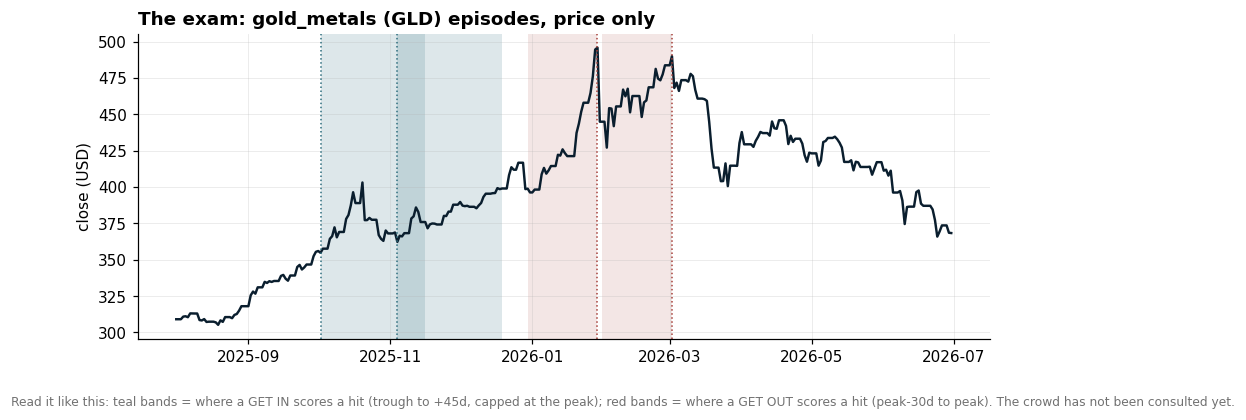

In [2]:
px = pxmap[SYM].dropna()
win_px = px.loc[WIN_LO:WIN_HI]
fig, ax = plt.subplots(figsize=(10, 3.6))
ax.plot(win_px.index, win_px.values, color=NAVY, lw=1.6)
for ep in eps_g.itertuples():
    if ep.peak < WIN_LO or ep.trough > WIN_HI:
        continue
    ax.axvspan(ep.onset_lo, ep.onset_hi, color=TEAL, alpha=0.16, lw=0)
    ax.axvspan(ep.peak - pd.Timedelta(days=30), ep.peak, color=BEAR,
               alpha=0.13, lw=0)
    for d, c in ((ep.trough, TEAL), (ep.peak, BEAR)):
        ax.axvline(d, color=c, lw=1, ls=":")
ax.set_title(f"The exam: {NAME} ({SYM}) episodes, price only")
ax.set_ylabel("close (USD)")
fig.text(0.01, -0.06,
         "Read it like this: teal bands = where a GET IN scores a hit (trough to +45d, capped at the peak); "
         "red bands = where a GET OUT scores a hit (peak-30d to peak). The crowd has not been consulted yet.",
         fontsize=8, color=GRAY)
save(fig, "W1_the_exam.png")
plt.show()

---
# 1.5 — The actual posts, and the machine that reads them

**WHY THIS**

* Everything after this section is arithmetic on counts. A reviewer is
  entitled to see the thing being counted: *real gold posts, and the
  exact five steps that turn one of them into a row of numbers.*
* It also makes the **text-free boundary** concrete. The raw archives
  below are gitignored and live on the pull machine only; the text is
  opened here, clipped to 90 characters for display, and thrown away.
  What the repository commits — and what every number in §2 onward is
  built from — is counts and scores, never text.

In [3]:
# STEP 0 - the raw archive: gold posts, as they arrive
import io                                                    # noqa: E402
import json as _json                                         # noqa: E402

try:
    import zstandard as _zstd
except ImportError:                                          # pragma: no cover
    _zstd = None

from src.themes import themes_in_text                        # noqa: E402
from src.extract_tickers import (                            # noqa: E402
    extract_tickers_from_text)
from src.sentiment import (score_text, BULL_CUTOFF,          # noqa: E402
                           BEAR_CUTOFF)
from src.abstracted_data import load_universe                # noqa: E402

_RAW_TRY = [
    ("StockTwits", "data/raw/StockTwits/stocktwits_2026-08-06.jsonl.zst",
     "body"),
    ("Reddit comments",
     "data/raw/RedditComments/comments_2026-08-06.jsonl.zst", "body"),
    ("Reddit submissions",
     "data/raw/RedditLive/reddit_live_arctic_2026-08-06_094556.jsonl.zst",
     "title"),
]

_gold_posts, _scanned, _src_used = [], 0, None
for _label, _path, _tfield in _RAW_TRY:
    if _zstd is None or not (ROOT / _path).exists():
        continue
    with open(ROOT / _path, "rb") as _f:
        _t = io.TextIOWrapper(
            _zstd.ZstdDecompressor().stream_reader(_f), encoding="utf-8")
        for _line in _t:
            _scanned += 1
            try:
                _r = _json.loads(_line)
            except ValueError:
                continue
            _txt = _r.get(_tfield) or _r.get("body") or _r.get("title") or ""
            if "gold_metals" in themes_in_text(_txt):
                _gold_posts.append((_label, _r, _txt))
            if len(_gold_posts) >= 6:
                break
    _src_used = _label
    if _gold_posts:
        break

if not _gold_posts:
    print("(no raw archive on this machine - the pull machine holds them; "
          "every number below is built from the committed counts, which "
          "is the whole point of the abstracted layer)")
else:
    print(f"source: {_src_used} | posts scanned: {_scanned:,} | "
          f"showing the first {min(4, len(_gold_posts))} that mention gold")
    print("fields on a raw record:",
          sorted(_gold_posts[0][1].keys())[:9], "...")
    print()
    for _i, (_lab, _r, _txt) in enumerate(_gold_posts[:4], 1):
        print(f"  post {_i}  [{_lab}]  text[:90] = "
              f"{_txt[:90]!r}")

source: StockTwits | posts scanned: 450 | showing the first 4 that mention gold
fields on a raw record: ['body', 'created_at', 'discussion', 'entities', 'id', 'mentioned_users', 'prices', 'source', 'symbols'] ...

  post 1  [StockTwits]  text[:90] = '$GLD gold should be around $2000-2500 range. Hopium and memes drove this up. Kind of wild '
  post 2  [StockTwits]  text[:90] = '$GLD $SLV $DXY \n\nPlease don&#39;t meme this again so Jane Street jumps in and longs then s'
  post 3  [StockTwits]  text[:90] = 'Gold Rises Above $4,250 On US–Iran Deal Hopes $GLD $XAU $UUP https://talkmarkets.com/artic'
  post 4  [StockTwits]  text[:90] = 'Keep your eyes on precious metals 👀  \n$SLV  \n$GLD'


**HOW ONE POST BECOMES NUMBERS — the five steps, run in the open**

The cell below applies the SAME functions ingestion calls
(`src/themes.themes_in_text`, `src/extract_tickers`,
`src/sentiment.score_text`) to those exact posts, so the table is the
transform itself, not a description of it.

In [4]:
if _gold_posts:
    _uni = load_universe()
    _rows_tr = []
    for _lab, _r, _txt in _gold_posts[:4]:
        _th = sorted(themes_in_text(_txt))
        _tk = sorted(set(extract_tickers_from_text(
            _txt, _uni, cashtags_only=False)))
        _s = score_text(_txt)
        _rows_tr.append({
            "1. the post (clipped)": _txt[:52].replace("\n", " ") + "…",
            "2. themes found": ", ".join(_th),
            "3. tickers found": ", ".join(_tk[:4]) or "—",
            "4. sentiment (VADER+WSB)": round(_s, 3),
            "5. counts as": ("BULLISH" if _s > BULL_CUTOFF else
                             "BEARISH" if _s < BEAR_CUTOFF else "neutral"),
        })
    display(pd.DataFrame(_rows_tr))
    print(f"cut-offs: bullish if sentiment > {BULL_CUTOFF}, bearish if "
          f"< {BEAR_CUTOFF} (VADER convention, unchanged)")
    print("counting rule: ONE POST = ONE VOTE - a post naming gold five "
          "times counts once (breadth of attention, not verbosity)")

sentiment engine: vader+wsb (7,548 lexicon terms)


,1. the post (clipped),2. themes found,3. tickers found,4. sentiment (VADER+WSB),5. counts as
0,$GLD gold should be around $2000-2500 range. H...,gold_metals,GLD,0.077,BULLISH
1,$GLD $SLV $DXY Please don&#39;t meme this ag...,gold_metals,"GLD, SLV",-0.710,BEARISH
2,"Gold Rises Above $4,250 On US–Iran Deal Hopes ...",gold_metals,"GLD, UUP",0.421,BULLISH
3,Keep your eyes on precious metals 👀 $SLV $...,gold_metals,"GLD, SLV",0.572,BULLISH


cut-offs: bullish if sentiment > 0.05, bearish if < -0.05 (VADER convention, unchanged)
counting rule: ONE POST = ONE VOTE - a post naming gold five times counts once (breadth of attention, not verbosity)


figure -> docs/figures/06/W0_raw_to_numbers.png


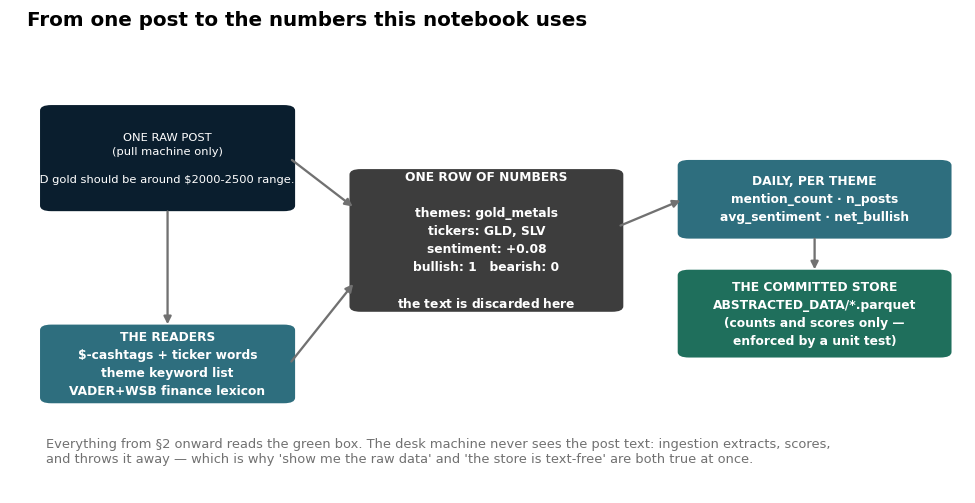

In [5]:
# W0 - the transform on one slide: post -> row of numbers -> the series
# the rest of this notebook uses
import matplotlib.patches as _mp                             # noqa: E402

_fig, _ax = plt.subplots(figsize=(11, 5.4))
_ax.set_xlim(0, 100)
_ax.set_ylim(0, 100)
_ax.axis("off")


def _bx(x, y, w, h, txt, fc, tc="white", fs=8.5, weight="bold"):
    _ax.add_patch(_mp.FancyBboxPatch(
        (x, y), w, h, boxstyle="round,pad=0.6,rounding_size=1.2",
        facecolor=fc, edgecolor="none"))
    _ax.text(x + w / 2, y + h / 2, txt, ha="center", va="center",
             color=tc, fontsize=fs, fontweight=weight, linespacing=1.5)


def _ar(x0, y0, x1, y1, c=GRAY):
    _ax.annotate("", (x1, y1), (x0, y0),
                 arrowprops=dict(arrowstyle="-|>", lw=1.5, color=c))


# NB: matplotlib parses $...$ as LaTeX math - cashtags MUST be escaped
# or "$GLD ... $2000" renders as italic gibberish (caught 2026-08-10)
_ex = ((_gold_posts[0][2][:46].replace("\n", " ") + "…") if _gold_posts
       else "$GLD gold should be around $2000-2500…").replace("$", r"\$")
_bx(2, 62, 26, 22,
    "ONE RAW POST\n(pull machine only)\n\n" + f"“{_ex}”",
    NAVY, fs=7.5, weight="normal")
_bx(2, 20, 26, 16,
    "THE READERS\n$-cashtags + ticker words\ntheme keyword list\nVADER+WSB "
    "finance lexicon", TEAL, fs=8)
_ar(15, 62, 15, 36)
_bx(35, 40, 28, 30,
    "ONE ROW OF NUMBERS\n\nthemes: gold_metals\ntickers: GLD, SLV\n"
    "sentiment: +0.08\nbullish: 1   bearish: 0\n\n"
    "$\\bf{the\\ text\\ is\\ discarded\\ here}$", "#3d3d3d", fs=8)
_ar(28, 73, 35, 62)
_ar(28, 28, 35, 46)
_bx(70, 56, 28, 16,
    "DAILY, PER THEME\nmention_count · n_posts\navg_sentiment · net_bullish",
    TEAL, fs=8)
_bx(70, 30, 28, 18,
    "THE COMMITTED STORE\nABSTRACTED_DATA/*.parquet\n"
    "(counts and scores only —\nenforced by a unit test)", BULL, fs=8)
_ar(63, 58, 70, 64)
_ar(84, 56, 84, 48)
_ax.text(2, 12,
         "Everything from §2 onward reads the green box. The desk machine never sees the post text: ingestion "
         "extracts, scores,\nand throws it away — which is why 'show me the raw data' and 'the store is text-free' "
         "are both true at once.",
         fontsize=8.5, color=GRAY, va="top")
_ax.set_title("From one post to the numbers this notebook uses",
              fontsize=13, fontweight="bold", loc="left")
save(_fig, "W0_raw_to_numbers.png")
plt.show()

**SO WHAT**

* The chain has no hidden step: a post is read by three plain
  dictionaries (cashtags, theme keywords, a finance sentiment lexicon),
  becomes one row of integers and one score, and is then deleted.
* The counting rule matters for reading §2: **one post = one vote**, so
  "attention" is the number of *people talking*, not the number of
  times a word appears — a single ranting post cannot move the series.

**IF ASKED — "how good is the sentiment scorer?"** It is finVADER plus
a WSB/finance lexicon (7,548 terms), chosen over FinBERT and an LLM in
the notebook-10 tournament on cost-per-accuracy; the record is
`docs/research/nb10_ai_sentiment.json`. It is deliberately simple: the
desk signal uses the mood BLOCK (level, persistence, turning), not any
single post's score.

---
# 2 — The crowd's raw series for gold (what the stores actually hold)

the actual store rows, five days into the January blow-off:
            mentions that day  tagged posts  net-bullish share
date                                                          
2026-01-12                 73            73              0.452
2026-01-13                 74            74              0.486
2026-01-14                 76            76              0.592
2026-01-15                 71            71              0.352
2026-01-16                 46            46              0.348


figure -> docs/figures/06/W2_raw_series.png


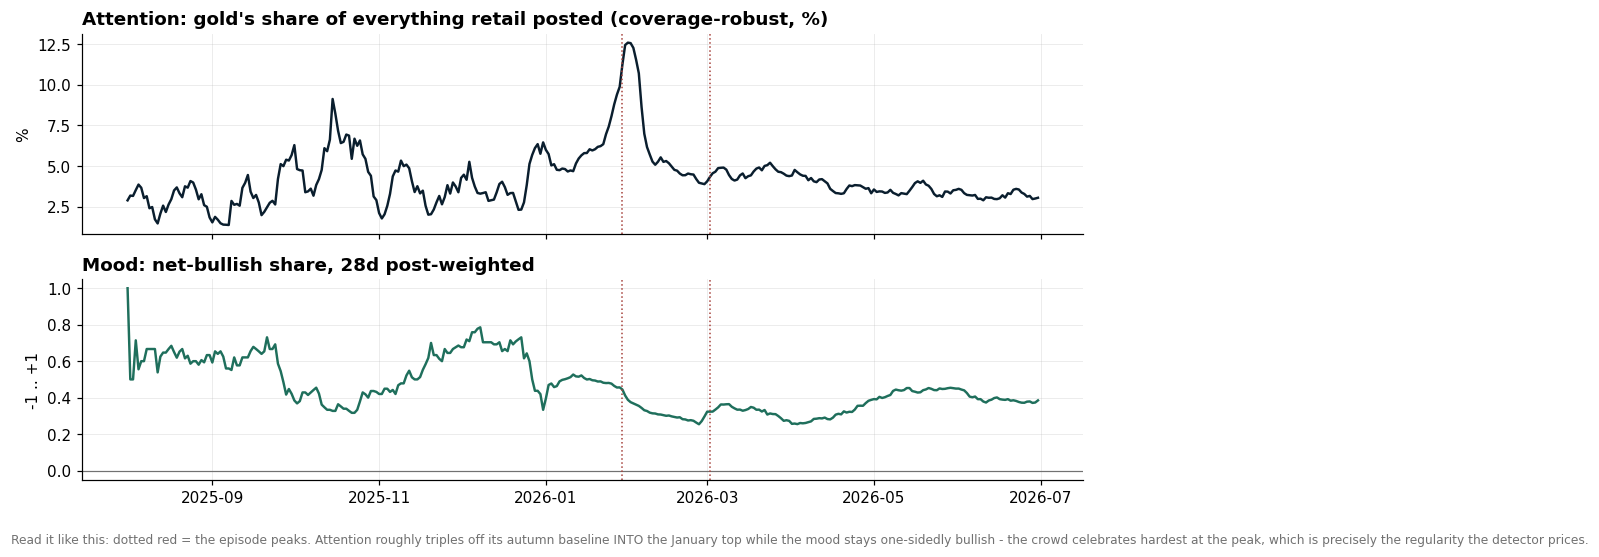

In [6]:
gcount = (counts["theme"][counts["theme"]["theme"] == NAME]
          .set_index("date")["mention_count"].sort_index())
gsent = sents["theme"][sents["theme"]["theme"] == NAME].set_index("date")
print("the actual store rows, five days into the January blow-off:")
show = pd.DataFrame({
    "mentions that day": gcount,
    "tagged posts": gsent["n_posts"],
    "net-bullish share": gsent["net_bullish"].round(3),
}).loc["2026-01-12":"2026-01-16"]
print(show.to_string())

from analytics.robust_share import robust_share              # noqa: E402
from analytics.overlays import sentiment_series              # noqa: E402
all_days = pd.date_range(counts["theme"]["date"].min(),
                         counts["theme"]["date"].max(), freq="D")
gshare = robust_share(counts["theme"], "theme", NAME, all_days)
gmood = sentiment_series(sents["theme"], "theme", NAME, WIN_LO, WIN_HI)

fig, axes = plt.subplots(2, 1, figsize=(10, 4.8), sharex=True)
s = gshare.loc[WIN_LO:WIN_HI]
axes[0].plot(s.index, s.values, color=NAVY, lw=1.6)
axes[0].set_title("Attention: gold's share of everything retail posted "
                  "(coverage-robust, %)")
axes[0].set_ylabel("%")
m = gmood.loc[WIN_LO:WIN_HI]
axes[1].plot(m.index, m.values, color=BULL, lw=1.6)
axes[1].axhline(0, color=GRAY, lw=0.8)
axes[1].set_title("Mood: net-bullish share, 28d post-weighted")
axes[1].set_ylabel("-1 .. +1")
for ax in axes:
    for ep in eps_g.itertuples():
        if WIN_LO <= ep.peak <= WIN_HI:
            ax.axvline(ep.peak, color=BEAR, lw=1, ls=":")
fig.text(0.01, -0.04,
         "Read it like this: dotted red = the episode peaks. Attention roughly triples off its autumn baseline "
         "INTO the January top while the mood stays one-sidedly bullish - the crowd celebrates hardest at the "
         "peak, which is precisely the regularity the detector prices.",
         fontsize=8, color=GRAY)
fig.tight_layout()
save(fig, "W2_raw_series.png")
plt.show()

---
# 3 — The 11 measurements, and what they read on the day that mattered

figure -> docs/figures/06/W3_the_measurements.png


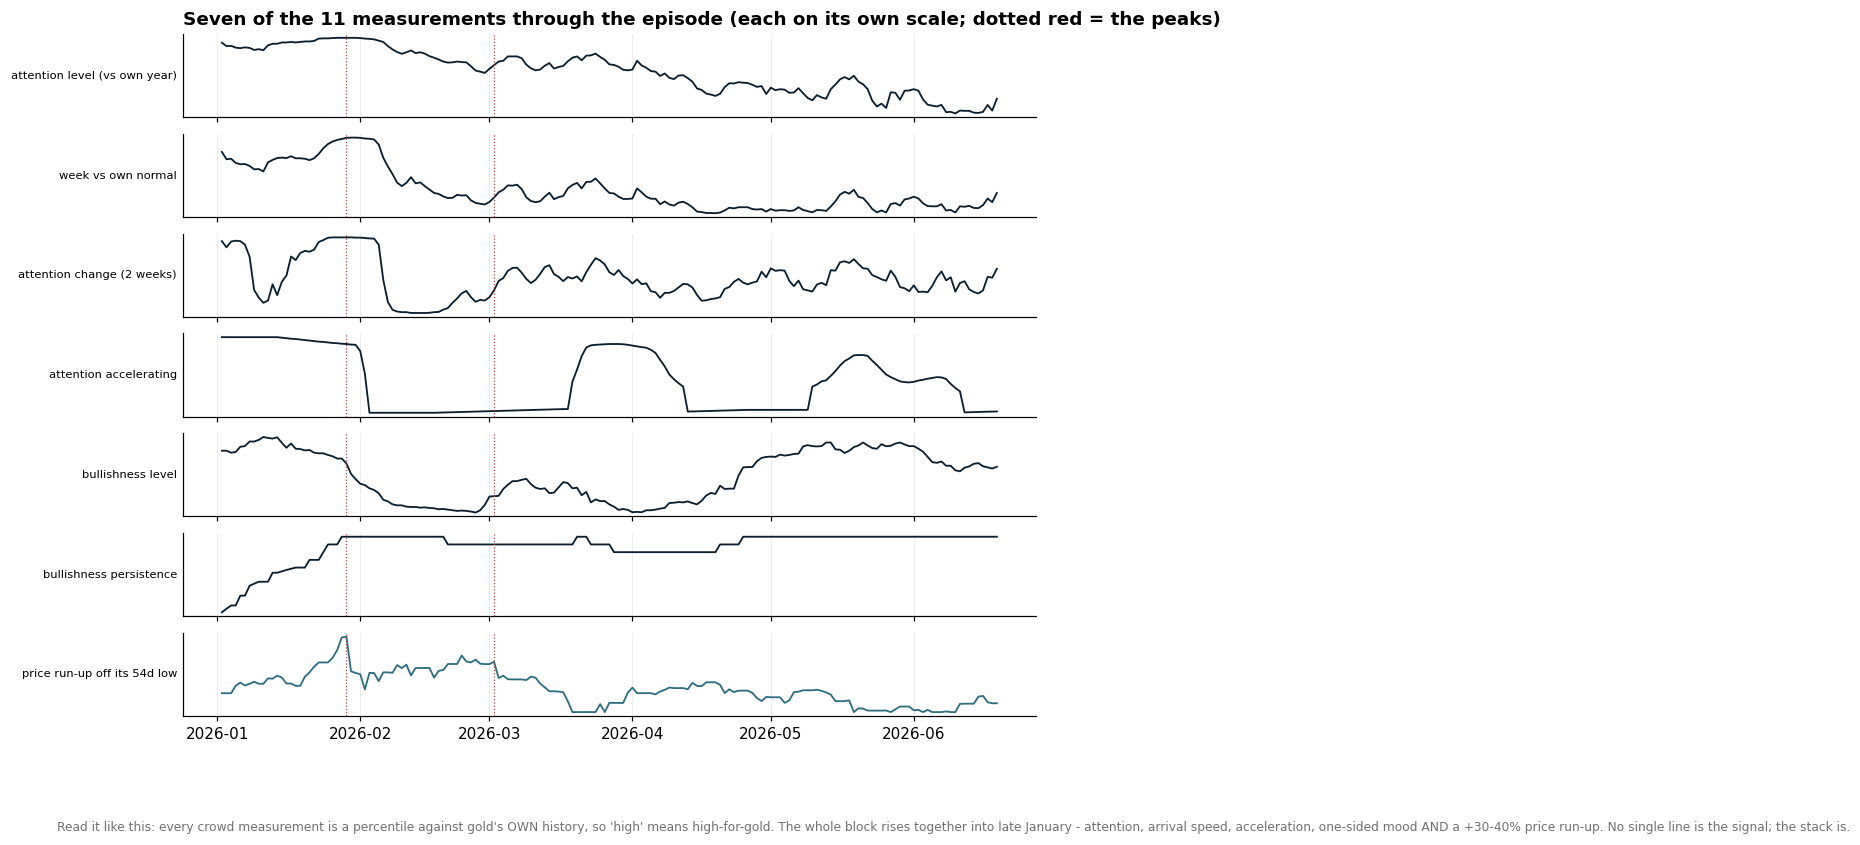

In [7]:
g = cand[cand["name"] == NAME].set_index("date").sort_index()
FEATS_SHOW = ["e1", "hype_ratio", "influx_speed", "attention_convexity",
              "bull_level", "bull_persist", "price_runup"]
fig, axes = plt.subplots(len(FEATS_SHOW), 1,
                         figsize=(10, 1.15 * len(FEATS_SHOW)),
                         sharex=True)
for ax, f in zip(axes, FEATS_SHOW):
    v = g[f].loc[WIN_LO:WIN_HI]
    ax.plot(v.index, v.values, color=TEAL if f.startswith(("price",))
            else NAVY, lw=1.2)
    ax.set_ylabel(mld.ML_BANK_LABELS.get(f, f), rotation=0, ha="right",
                  fontsize=7.5, va="center")
    ax.set_yticks([])
    for ep in eps_g.itertuples():
        if WIN_LO <= ep.peak <= WIN_HI:
            ax.axvline(ep.peak, color=BEAR, lw=0.8, ls=":")
axes[0].set_title("Seven of the 11 measurements through the episode "
                  "(each on its own scale; dotted red = the peaks)")
fig.text(0.01, -0.02,
         "Read it like this: every crowd measurement is a percentile against gold's OWN history, so 'high' "
         "means high-for-gold. The whole block rises together into late January - attention, arrival speed, "
         "acceleration, one-sided mood AND a +30-40% price run-up. No single line is the signal; the stack is.",
         fontsize=8, color=GRAY)
save(fig, "W3_the_measurements.png")
plt.show()

---
# 4 — The model turns the stack into one probability — and fires

walk-forward GET OUT alerts for gold_metals: ['2018-09-27', '2022-03-08', '2022-12-18', '2026-01-23']
the 2026 test-year cut (chosen on <=2025 data only): 0.921


figure -> docs/figures/06/W4_the_call.png


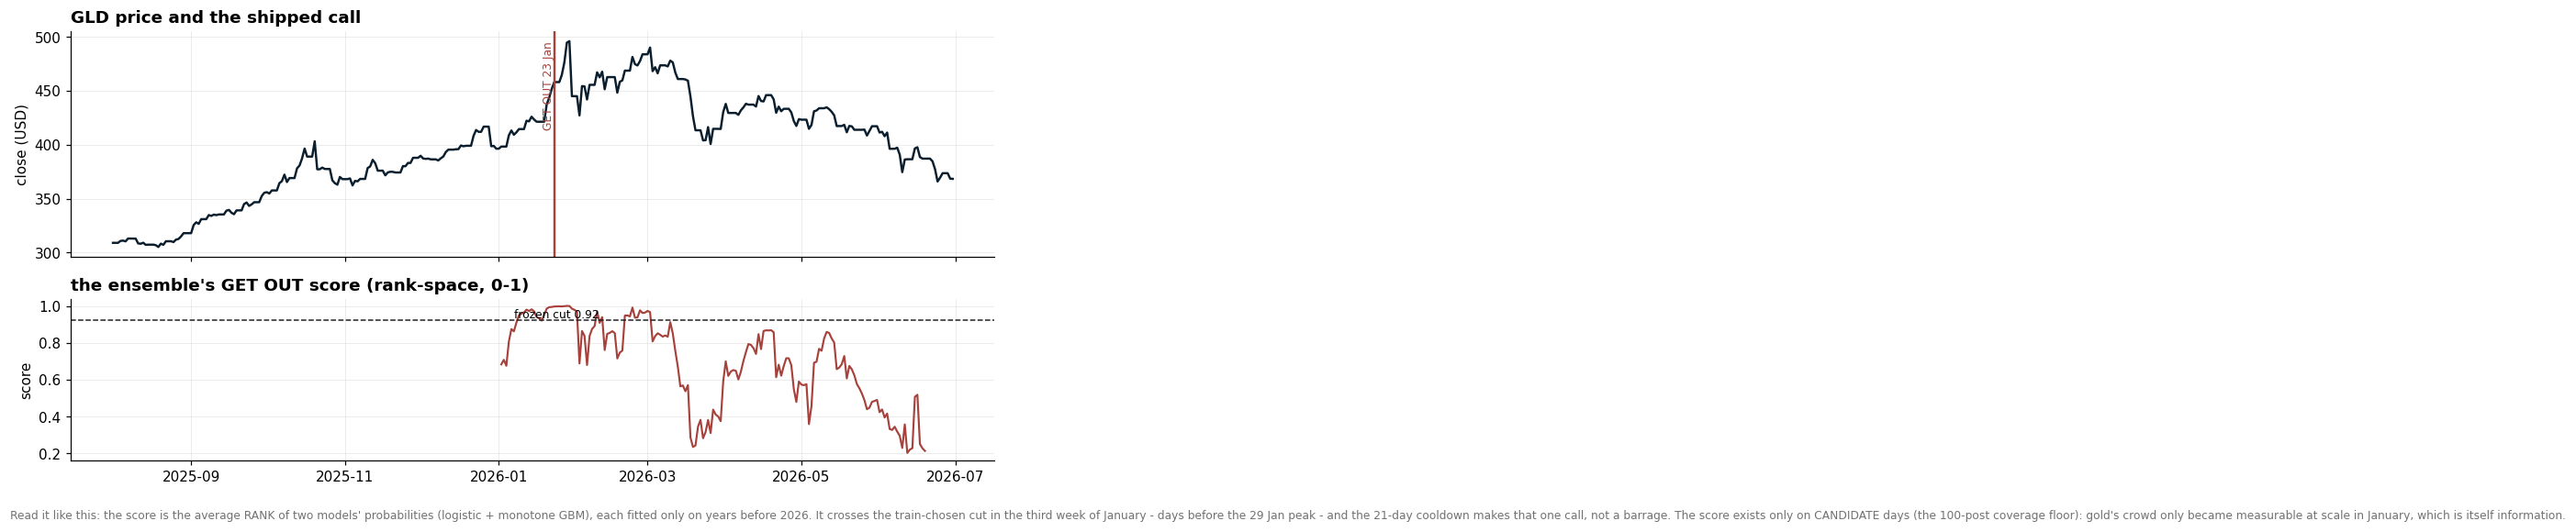

In [8]:
# the walk-forward alerts for gold, from the same machinery notebook 03
# grades (fit on years < each test year, F1 cut on train years, 21d
# cooldown) - then rendered as the probability path for 2025-26
wf_out = run_tournament_entry(cand, episodes, mld.DESK_ML_BANK, "y_top",
                              "top", mld.make_ens_fit("y_top"),
                              EUPHORIA_FA_BUDGET_PER_IY,
                              chooser=mld.choose_threshold_f1)
alerts_gold = sorted(wf_out["alerts_by_name"].get(NAME, []))
thr_2026 = wf_out["thresholds"].get(2026)
print(f"walk-forward GET OUT alerts for {NAME}: "
      f"{[f'{pd.Timestamp(a):%Y-%m-%d}' for a in alerts_gold]}")
print(f"the 2026 test-year cut (chosen on <=2025 data only): "
      f"{thr_2026:.3f}")

# score the 2026 window with the same fit the walk-forward used
train = cand[cand["year"] < 2026]
prob = pd.Series(
    mld.make_ens_fit("y_top")(train, g.reset_index(), mld.DESK_ML_BANK),
    index=g.index).loc[WIN_LO:WIN_HI]

fig, axes = plt.subplots(2, 1, figsize=(10, 5.0), sharex=True,
                         gridspec_kw={"height_ratios": [1.4, 1]})
axes[0].plot(win_px.index, win_px.values, color=NAVY, lw=1.6)
for a in alerts_gold:
    a = pd.Timestamp(a)
    if WIN_LO <= a <= WIN_HI:
        axes[0].axvline(a, color=BEAR, lw=1.6)
        axes[0].annotate(f"GET OUT {a:%d %b}", (a, win_px.max()),
                         rotation=90, fontsize=8, color=BEAR,
                         va="top", ha="right")
axes[0].set_title(f"{SYM} price and the shipped call")
axes[0].set_ylabel("close (USD)")
axes[1].plot(prob.index, prob.values, color=BEAR, lw=1.4)
if thr_2026:
    axes[1].axhline(thr_2026, color="#222222", lw=1, ls="--")
    axes[1].annotate(f"frozen cut {thr_2026:.2f}",
                     (prob.index[5], thr_2026), fontsize=8, va="bottom")
axes[1].set_title("the ensemble's GET OUT score (rank-space, 0-1)")
axes[1].set_ylabel("score")
fig.text(0.01, -0.04,
         "Read it like this: the score is the average RANK of two models' probabilities (logistic + monotone "
         "GBM), each fitted only on years before 2026. It crosses the train-chosen cut in the third week of "
         "January - days before the 29 Jan peak - and the 21-day cooldown makes that one call, not a barrage. "
         "The score exists only on CANDIDATE days (the 100-post coverage floor): gold's crowd only became "
         "measurable at scale in January, which is itself information.",
         fontsize=8, color=GRAY)
fig.tight_layout()
save(fig, "W4_the_call.png")
plt.show()

---
# 5 — The outcome, graded

In [9]:
for a in alerts_gold:
    a = pd.Timestamp(a)
    if not (WIN_LO <= a <= WIN_HI):
        continue
    p0 = px.asof(a)
    rows = []
    for h in (5, 21, 84):
        p1 = px.asof(a + pd.Timedelta(days=h))
        rows.append(f"{h:>3}d: {100 * (p1 / p0 - 1):+.1f}%")
    peak_after = px.loc[a:a + pd.Timedelta(days=45)]
    print(f"alert {a:%Y-%m-%d} @ {p0:.1f}: "
          f"peak within 45d on {peak_after.idxmax():%Y-%m-%d} "
          f"({100 * (peak_after.max() / p0 - 1):+.1f}%), then "
          f"trough {100 * (px.loc[a:a + pd.Timedelta(days=120)].min() / p0 - 1):+.1f}% | "
          f"forward moves: " + " | ".join(rows))

alert 2026-01-23 @ 458.0: peak within 45d on 2026-01-29 (+8.3%), then trough -12.5% | forward moves:   5d: +8.0% |  21d: +1.0% |  84d: -2.6%


**SO WHAT** — the grade: the January call lands inside the
`[peak−30d, peak]` window of the 29 Jan episode → **HIT**, with a
7-day lead; the subsequent drawdown clears the 12% bust bar, so the
episode was worth having warned about. This is one worked instance of
the 92/218 the scorecard counts.

**IF ASKED — "did the model see any of this year when it fired?"** No.
The 2026 alerts come from a fit on 2017–2025 and a cut chosen on
2017–2025; 2026 was scored blind. That is true of every year in every
scorecard in this project.

---
# 6 — The same call, on the screen the PM uses

The dashboard's EUPHORIA: Themes tab draws gold from
`data/processed/euphoria_desk.parquet` — written by the live pipeline
with the SAME model at its frozen cut. Its stored gold calls:

In [10]:
desk = pd.read_parquet(Path(PROCESSED_DIR) / "euphoria_desk.parquet")
desk["date"] = pd.to_datetime(desk["date"])
gd = desk[desk["name"] == NAME]
print("GET OUT:", [f"{d:%Y-%m-%d}" for d in gd.loc[gd["get_out"], "date"]])
print("GET IN :", [f"{d:%Y-%m-%d}" for d in gd.loc[gd["get_in"], "date"]])
print("\n(The January GET OUT above is the same call as §4 - one model, "
      "one store; the walk-forward grader and the frozen-cut replay land "
      "within a day of each other. The "
      "2020 GET OUT is the frozen-cut replay of the 2020 gold top; the "
      "2026-02-23 GET IN fired into the second, March leg of the run.)")

GET OUT: ['2020-08-04', '2026-01-22']
GET IN : []

(The January GET OUT above is the same call as §4 - one model, one store; the walk-forward grader and the frozen-cut replay land within a day of each other. The 2020 GET OUT is the frozen-cut replay of the 2020 gold top; the 2026-02-23 GET IN fired into the second, March leg of the run.)
